# Encryption Quality — Visualisation
Generates publication-ready figures from `benchmarks/results/encryption_quality.json`.

Verifies that after encrypted cloning, all individual qubits (A, signal, noise) are maximally mixed (purity = 0.5).

**Theory:** Yamaguchi & Kempf, PRL 136(1), 2026 — Supplemental Material, "Proof that the encryption is perfect".

In [9]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

In [10]:
with open('results/encryption_quality.json', 'r') as f:
    data = json.load(f)

results = data['results']
summary = data['summary']
expected = data['metadata']['expected_purity']

ns = sorted(set(r['n_clones'] for r in results))
print(f"Trials: {len(results)}")
print(f"Clone counts: {ns}")
print(f"Expected purity: {expected}")

Trials: 400
Clone counts: [2, 3, 4, 5]
Expected purity: 0.5


## Figure 1: Mean Purity per Qubit Type vs n
All three qubit types (A, signal, noise) should sit at 0.5.

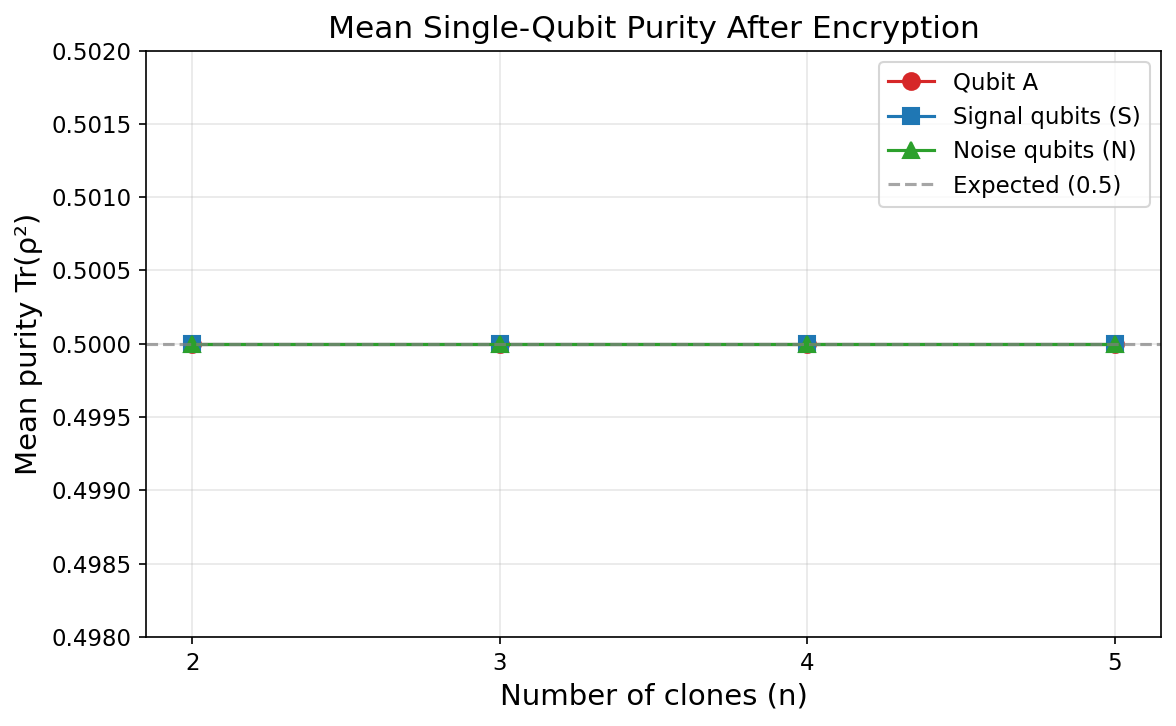

In [11]:
a_means = [row['a_mean_purity'] for row in summary]
s_means = [row['signal_mean_purity'] for row in summary]
n_means = [row['noise_mean_purity'] for row in summary]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ns, a_means, 'o-', color='#d62728', label='Qubit A', markersize=8)
ax.plot(ns, s_means, 's-', color='#1f77b4', label='Signal qubits (S)', markersize=8)
ax.plot(ns, n_means, '^-', color='#2ca02c', label='Noise qubits (N)', markersize=8)

ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.7, label='Expected (0.5)')

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Mean purity Tr(ρ²)')
ax.set_title('Mean Single-Qubit Purity After Encryption')
ax.set_xticks(ns)
ax.set_ylim(0.498, 0.502)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/encryption_mean_purity_vs_n.png')
plt.show()

## Figure 2: Maximum Deviation from 0.5 vs n
Shows the worst-case deviation across all random input states. Should be at machine epsilon.

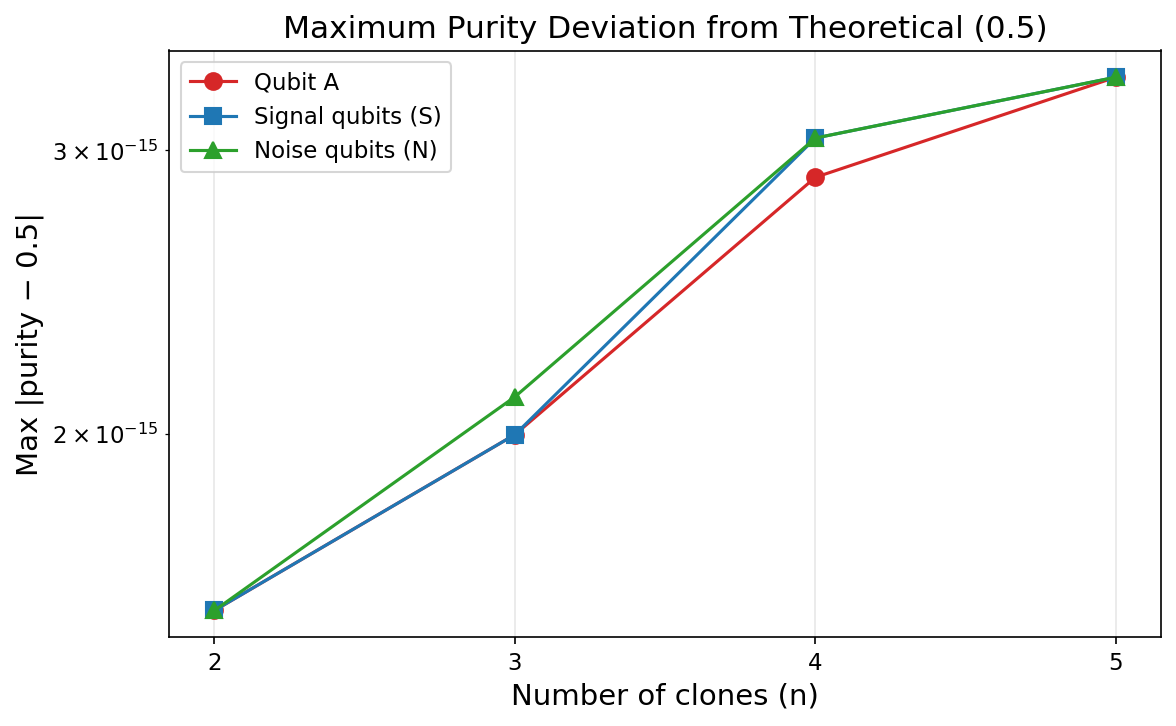

In [12]:
a_devs = [row['a_max_dev'] for row in summary]
s_devs = [row['signal_max_dev'] for row in summary]
n_devs = [row['noise_max_dev'] for row in summary]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ns, a_devs, 'o-', color='#d62728', label='Qubit A', markersize=8)
ax.plot(ns, s_devs, 's-', color='#1f77b4', label='Signal qubits (S)', markersize=8)
ax.plot(ns, n_devs, '^-', color='#2ca02c', label='Noise qubits (N)', markersize=8)

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Max |purity − 0.5|')
ax.set_title('Maximum Purity Deviation from Theoretical (0.5)')
ax.set_xticks(ns)
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/encryption_max_deviation_vs_n.png')
plt.show()

## Figure 3: Purity Distribution per Clone (Signal Qubits)
Box plot showing purity spread across all random input states for each signal qubit at each n.

/var/folders/n1/sg7h_ykd3979zm0fkg2x8tx00000gn/T/ipykernel_7062/2876356658.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
/var/folders/n1/sg7h_ykd3979zm0fkg2x8tx00000gn/T/ipykernel_7062/2876356658.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
/var/folders/n1/sg7h_ykd3979zm0fkg2x8tx00000gn/T/ipykernel_7062/2876356658.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
/var/folders/n1/sg7h_ykd3979zm0fkg2x8tx00000gn/T/

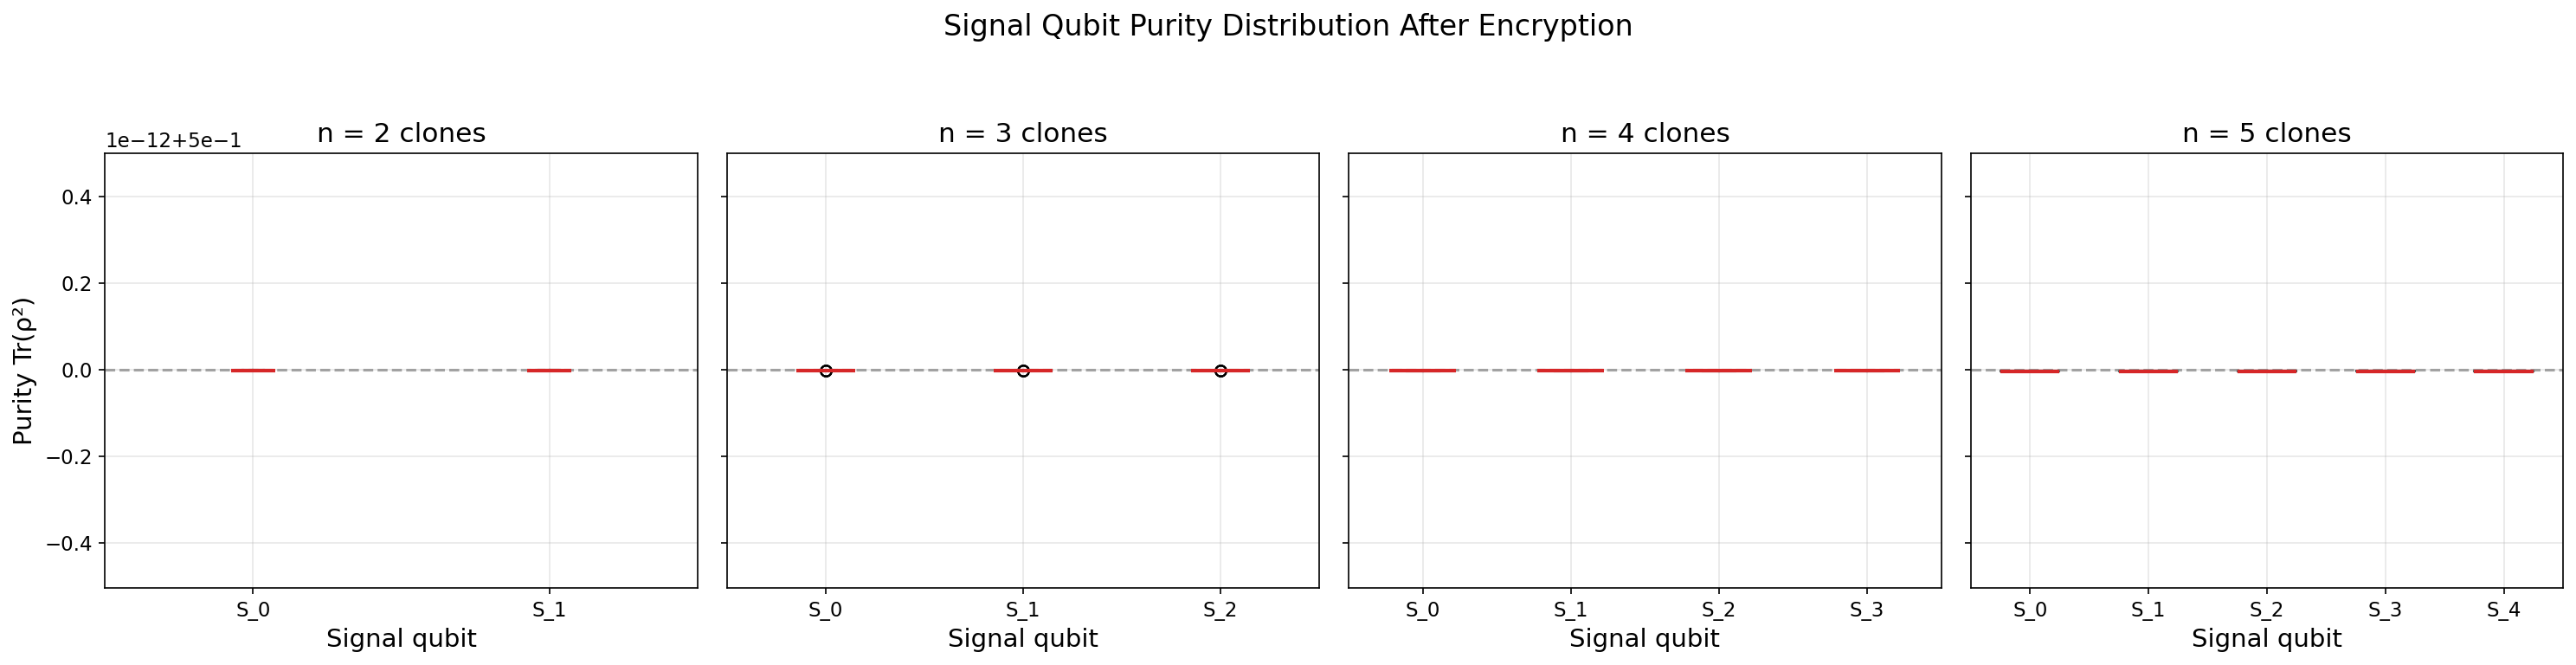

In [13]:
fig, axes = plt.subplots(1, len(ns), figsize=(5*len(ns), 5), sharey=True)
if len(ns) == 1:
    axes = [axes]

for idx, n in enumerate(ns):
    ax = axes[idx]
    sub = [r for r in results if r['n_clones'] == n]
    
    box_data = []
    box_labels = []
    for j in range(n):
        purities = [r['signal_purities'][j]['purity'] for r in sub]
        box_data.append(purities)
        box_labels.append(f'S_{j}')
    
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    boxprops=dict(facecolor='#aec7e8', alpha=0.7),
                    medianprops=dict(color='#d62728', linewidth=2))
    
    ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.7)
    ax.set_xlabel('Signal qubit')
    if idx == 0:
        ax.set_ylabel('Purity Tr(ρ²)')
    ax.set_title(f'n = {n} clones')
    ax.grid(True, alpha=0.3)

plt.suptitle('Signal Qubit Purity Distribution After Encryption', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figures/encryption_signal_purity_boxplot.png')
plt.show()

## Figure 4: All Individual Purities Scatter
Every measured purity value (A, all S, all N) for every trial, coloured by qubit type.

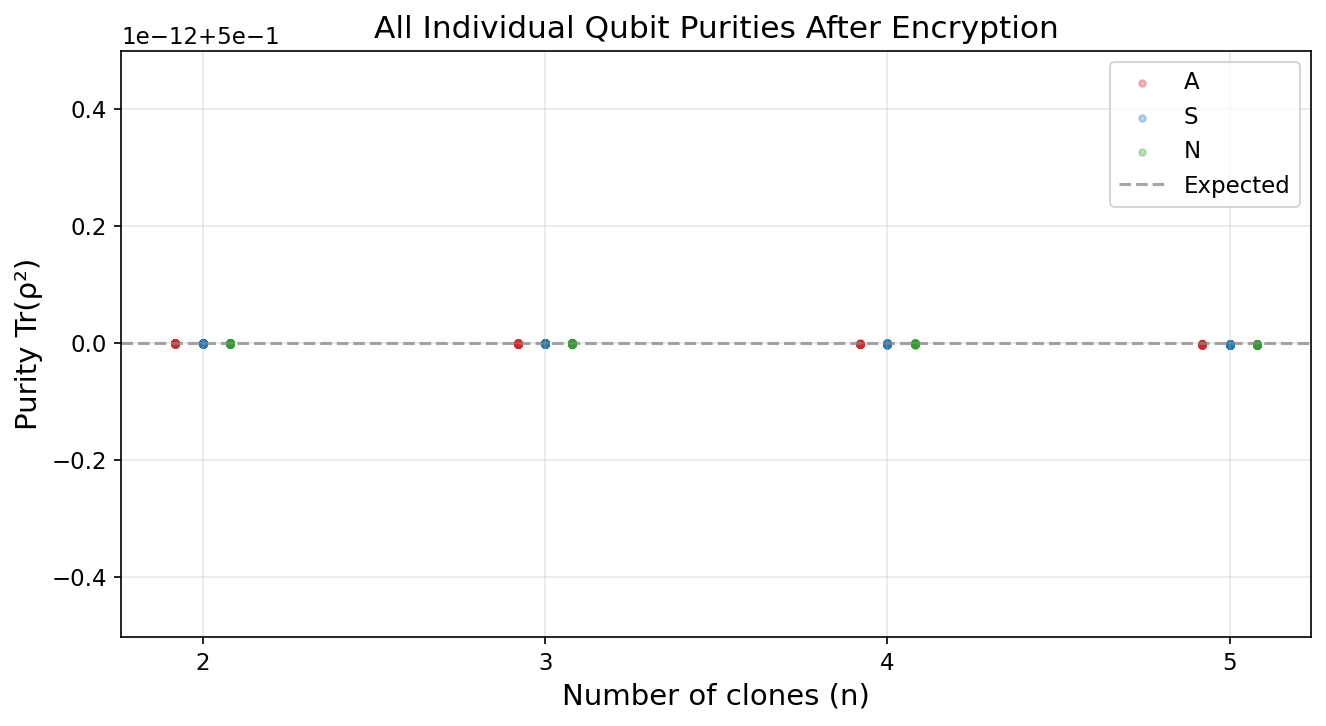

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for n in ns:
    sub = [r for r in results if r['n_clones'] == n]
    
    a_purs = [r['a_purity'] for r in sub]
    s_purs = [s['purity'] for r in sub for s in r['signal_purities']]
    n_purs = [nq['purity'] for r in sub for nq in r['noise_purities']]
    
    jitter = 0.08
    ax.scatter([n - jitter]*len(a_purs), a_purs,
              alpha=0.3, s=10, color='#d62728', label='A' if n == ns[0] else '')
    ax.scatter([n]*len(s_purs), s_purs,
              alpha=0.3, s=10, color='#1f77b4', label='S' if n == ns[0] else '')
    ax.scatter([n + jitter]*len(n_purs), n_purs,
              alpha=0.3, s=10, color='#2ca02c', label='N' if n == ns[0] else '')

ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.7, label='Expected')

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Purity Tr(ρ²)')
ax.set_title('All Individual Qubit Purities After Encryption')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/encryption_all_purities_scatter.png')
plt.show()

## Figure 5: Pass/Fail Heatmap
Shows whether all qubits of each type pass the purity check at each n.

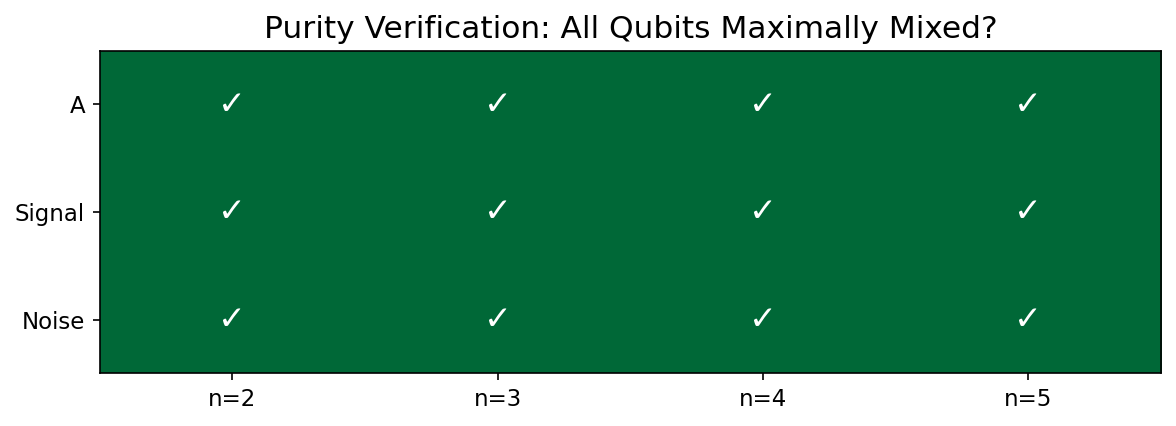

In [15]:
qubit_types = ['A', 'Signal', 'Noise']
pass_matrix = np.zeros((len(qubit_types), len(ns)))

for j, row in enumerate(summary):
    pass_matrix[0, j] = 1.0 if row['a_all_mixed'] else 0.0
    pass_matrix[1, j] = 1.0 if row['signal_all_mixed'] else 0.0
    pass_matrix[2, j] = 1.0 if row['noise_all_mixed'] else 0.0

fig, ax = plt.subplots(figsize=(8, 3))

cmap = plt.cm.RdYlGn
im = ax.imshow(pass_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(ns)))
ax.set_xticklabels([f'n={n}' for n in ns])
ax.set_yticks(range(len(qubit_types)))
ax.set_yticklabels(qubit_types)
ax.set_title('Purity Verification: All Qubits Maximally Mixed?')

for i in range(len(qubit_types)):
    for j in range(len(ns)):
        text = '✓' if pass_matrix[i, j] == 1.0 else '✗'
        ax.text(j, i, text, ha='center', va='center', fontsize=16,
                color='white' if pass_matrix[i, j] == 1.0 else 'black')

plt.tight_layout()
plt.savefig('figures/encryption_pass_fail_heatmap.png')
plt.show()

---
## Summary Table

In [16]:
print('='*80)
print('ENCRYPTION QUALITY SUMMARY')
print(f'Expected purity: {expected} (maximally mixed)')
print('='*80)
print(f"{'n':>4}  {'Trials':>6}  "
      f"{'A purity':>10}  {'A ok':>4}  "
      f"{'S purity':>10}  {'S ok':>4}  "
      f"{'N purity':>10}  {'N ok':>4}")
print('-'*70)

for row in summary:
    a_ok = '✓' if row['a_all_mixed'] else '✗'
    s_ok = '✓' if row['signal_all_mixed'] else '✗'
    n_ok = '✓' if row['noise_all_mixed'] else '✗'
    print(f"{row['n_clones']:>4}  {row['trials']:>6}  "
          f"{row['a_mean_purity']:>10.8f}  {a_ok:>4}  "
          f"{row['signal_mean_purity']:>10.8f}  {s_ok:>4}  "
          f"{row['noise_mean_purity']:>10.8f}  {n_ok:>4}")

print()
print('Max deviations from 0.5:')
for row in summary:
    print(f"  n={row['n_clones']}: "
          f"A={row['a_max_dev']:.2e}  "
          f"S={row['signal_max_dev']:.2e}  "
          f"N={row['noise_max_dev']:.2e}")

ENCRYPTION QUALITY SUMMARY
Expected purity: 0.5 (maximally mixed)
   n  Trials    A purity  A ok    S purity  S ok    N purity  N ok
----------------------------------------------------------------------
   2     100  0.50000000     ✓  0.50000000     ✓  0.50000000     ✓
   3     100  0.50000000     ✓  0.50000000     ✓  0.50000000     ✓
   4     100  0.50000000     ✓  0.50000000     ✓  0.50000000     ✓
   5     100  0.50000000     ✓  0.50000000     ✓  0.50000000     ✓

Max deviations from 0.5:
  n=2: A=1.55e-15  S=1.55e-15  N=1.55e-15
  n=3: A=2.00e-15  S=2.00e-15  N=2.11e-15
  n=4: A=2.89e-15  S=3.05e-15  N=3.05e-15
  n=5: A=3.33e-15  S=3.33e-15  N=3.33e-15
